In [1]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("../data/processed_fraud_dataset.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (6362620, 17)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,is_transfer_or_cashout,orig_balance_error,dest_balance_error,is_full_transfer,amount_balance_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,0,1.455192e-11,9839.64,0,0.057834,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,0,-1.136868e-12,1864.28,0,0.087731,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,1,0.000000e+00,181.00,1,0.994505,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,1,0.000000e+00,21363.00,1,0.994505,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,0,0.000000e+00,11668.14,0,0.280788,False,False,True,False


In [ ]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print(scale_pos_weight)

773.7482496194825


In [5]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:,1]

In [7]:
from sklearn.metrics import roc_auc_score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_auc)

[[1270876       5]
 [      4    1639]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC AUC: 0.9998113155393433


Precision and recall of 99.7, newly added feature might be too deterministic.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

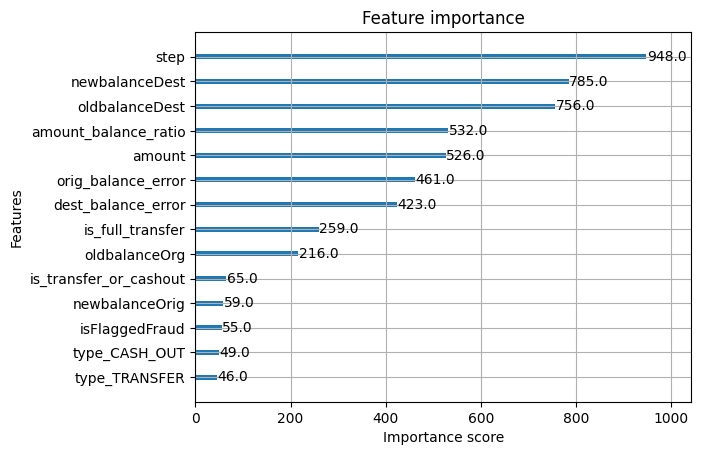

In [8]:
xgb.plot_importance(xgb_model)

Amount balance ratio is also one of the crucial feature, which could have lead to higher precision and recall.